# Weather Disruption Index — EDA Notebook

This notebook loads the cleaned hourly weather features and performs exploratory data analysis (EDA):

- Dataset overview & schema check
- Missingness summary & visualization
- Distributions and seasonal patterns
- Correlations (numerical features)
- Airport-level summaries
- Outlier checks
- Optional: save a trimmed, model-ready dataset

> **Tip:** Run the setup cell below first to install any missing packages.


In [1]:
# --- Setup (run once if needed) ---
# This cell installs optional utilities used in this notebook.
import sys, subprocess
def pip_install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

for p in ["pandas", "numpy", "matplotlib", "pyarrow"]:
    pip_install(p)

# missingno is optional for the matrix plot; we guard its import later
try:
    __import__("missingno")
except ImportError:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'missingno'])
    except Exception:
        pass  # continue without it


In [9]:
pip install jinja2


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-win_amd64.whl (15 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.


In [2]:
# --- Imports ---
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


In [3]:
# --- Load Data (tries both common project layouts) ---
ROOT = Path.cwd()
candidates = [
    ROOT / 'cleaned' / 'hourly_features.csv',              # current layout
    ROOT / 'data' / 'processed' / 'hourly_features.csv',   # clean layout
    ROOT.parent / 'cleaned' / 'hourly_features.csv',       # if notebook is in a subfolder
    ROOT.parent / 'data' / 'processed' / 'hourly_features.csv',
]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find 'hourly_features.csv' in cleaned/ or data/processed/ (tried multiple locations).")

print(f"Using file: {csv_path}")
df = pd.read_csv(csv_path, parse_dates=['DATE'])
print(df.shape)
df.head()


Using file: c:\Users\AviTx\Weather_Impact\weather_impact_team2\data\processed\hourly_features.csv
(693933, 19)


,ICAO,DATE,year,month,day,hour,tmp_c,dew_c,dew_spread_c,slp_hpa,vis_m,cig_m,wnd_dir,wnd_spd,is_low_vis,is_low_cig,LATITUDE,LONGITUDE,ELEVATION
0,KBNA,2019-01-01 00:00:00+00:00,2019,1,1,0,15.6,12.2,3.4,1011.9,16000.0,NaN,220.0,1.0,0,0,36.11889,-86.68917,182.9
1,KBNA,2019-01-01 00:53:00+00:00,2019,1,1,0,15.6,11.7,3.9,1012.6,16093.0,2438.0,230.0,5.0,0,0,36.11889,-86.68917,182.9
2,KBNA,2019-01-01 01:53:00+00:00,2019,1,1,1,15.0,11.7,3.3,1013.7,16093.0,2743.0,220.0,5.0,0,0,36.11889,-86.68917,182.9
3,KBNA,2019-01-01 02:10:00+00:00,2019,1,1,2,15.0,11.7,3.3,NaN,16093.0,762.0,220.0,5.0,0,0,36.11889,-86.68917,182.9
4,KBNA,2019-01-01 02:51:00+00:00,2019,1,1,2,14.0,11.0,3.0,NaN,16093.0,3658.0,240.0,5.0,0,0,36.11889,-86.68917,182.9


## 1) Overview & Schema

In [4]:
print("Columns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
display(df.describe(include='all'))
df.sample(min(5, len(df)))


Columns:
 ['ICAO', 'DATE', 'year', 'month', 'day', 'hour', 'tmp_c', 'dew_c', 'dew_spread_c', 'slp_hpa', 'vis_m', 'cig_m', 'wnd_dir', 'wnd_spd', 'is_low_vis', 'is_low_cig', 'LATITUDE', 'LONGITUDE', 'ELEVATION']

Dtypes:
 ICAO                         object
DATE            datetime64[ns, UTC]
year                          int64
month                         int64
day                           int64
hour                          int64
tmp_c                       float64
dew_c                       float64
dew_spread_c                float64
slp_hpa                     float64
vis_m                       float64
cig_m                       float64
wnd_dir                     float64
wnd_spd                     float64
is_low_vis                    int64
is_low_cig                    int64
LATITUDE                    float64
LONGITUDE                   float64
ELEVATION                   float64
dtype: object


,ICAO,DATE,year,month,day,hour,tmp_c,dew_c,dew_spread_c,slp_hpa,vis_m,cig_m,wnd_dir,wnd_spd,is_low_vis,is_low_cig,LATITUDE,LONGITUDE,ELEVATION
count,693933,693933,693933.000000,693933.000000,693933.000000,693933.000000,693933.000000,693933.000000,693933.000000,606869.000000,693905.000000,641032.000000,594916.000000,693922.000000,693933.000000,693933.000000,693933.000000,693933.000000,693933.000000
unique,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,KBNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,80414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2022-01-03 00:10:14.428193792+00:00,2021.509598,6.477131,15.752861,11.398613,17.742875,8.010250,9.732625,1015.474907,14845.742619,12663.713425,189.178192,5.132810,0.012374,0.057361,35.643042,-97.126285,345.318553
min,NaN,2019-01-01 00:00:00+00:00,2019.000000,1.000000,1.000000,0.000000,-30.000000,-35.600000,-1007.700000,979.500000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,28.418220,-122.233010,1.500000
25%,NaN,2020-06-27 08:53:00+00:00,2020.000000,3.000000,8.000000,6.000000,10.600000,-0.600000,3.300000,1011.100000,16000.000000,1829.000000,110.000000,5.000000,0.000000,0.000000,32.838390,-112.003650,27.100000
50%,NaN,2022-01-03 09:53:00+00:00,2022.000000,6.000000,16.000000,12.000000,18.300000,8.900000,6.700000,1015.300000,16093.000000,22000.000000,190.000000,5.000000,0.000000,0.000000,36.110540,-95.282120,178.900000
75%,NaN,2023-07-11 16:53:00+00:00,2023.000000,10.000000,23.000000,17.000000,25.600000,16.700000,13.900000,1019.600000,16093.000000,22000.000000,270.000000,5.000000,0.000000,0.000000,39.173300,-86.688150,339.200000
max,NaN,2024-12-31 23:56:00+00:00,2024.000000,12.000000,31.000000,23.000000,48.300000,999.900000,67.200000,1048.400000,28968.000000,22000.000000,360.000000,9.000000,1.000000,1.000000,41.786110,-76.684000,1650.200000


,ICAO,DATE,year,month,day,hour,tmp_c,dew_c,dew_spread_c,slp_hpa,vis_m,cig_m,wnd_dir,wnd_spd,is_low_vis,is_low_cig,LATITUDE,LONGITUDE,ELEVATION
587976,KOAK,2020-12-07 00:53:00+00:00,2020,12,7,0,14.4,8.3,6.1,1023.9,16093.0,7620.0,290.0,5.0,0,0,37.72140,-122.22080,1.8
98070,KBWI,2020-06-23 23:22:00+00:00,2020,6,23,23,27.2,23.3,3.9,NaN,16093.0,22000.0,70.0,5.0,0,0,39.17330,-76.68400,47.5
182638,KDAL,2021-11-03 22:43:00+00:00,2021,11,3,22,7.8,6.7,1.1,NaN,16093.0,274.0,30.0,5.0,0,1,32.83839,-96.83583,147.6
590625,KOAK,2021-03-10 09:53:00+00:00,2021,3,10,9,10.0,7.2,2.8,1014.0,14484.0,1219.0,180.0,5.0,0,0,37.71780,-122.23301,1.5
236881,KDEN,2020-08-11 13:53:00+00:00,2020,8,11,13,20.6,13.9,6.7,1010.5,16093.0,22000.0,NaN,9.0,0,0,39.83280,-104.65750,1650.2


## 2) Missingness Summary & (Optional) Matrix Plot

,missing_frac
wnd_dir,14.27%
slp_hpa,12.55%
cig_m,7.62%
vis_m,0.00%
wnd_spd,0.00%
ICAO,0.00%
DATE,0.00%
year,0.00%
tmp_c,0.00%
month,0.00%


<Figure size 640x480 with 0 Axes>

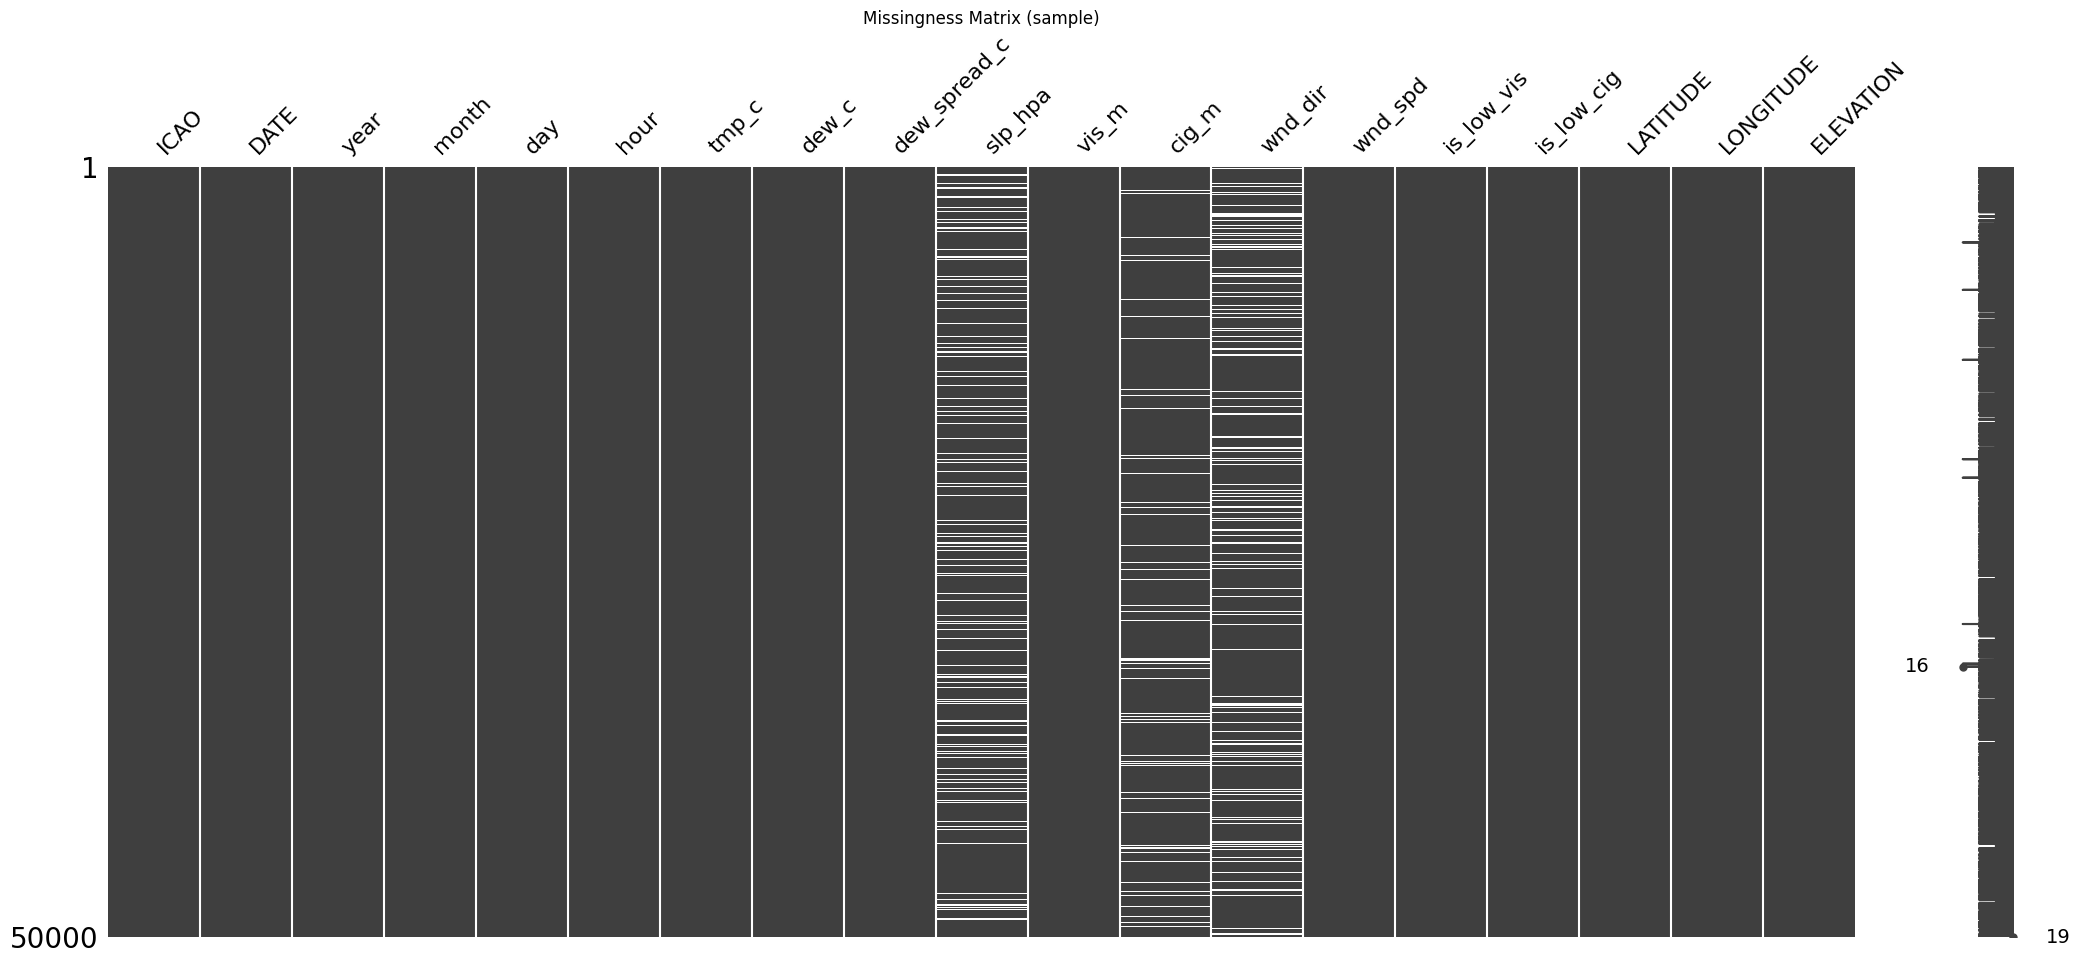

In [10]:
missing = df.isna().mean().sort_values(ascending=False)
display(missing.to_frame('missing_frac').style.format({"missing_frac": "{:.2%}"}))

# Optional matrix plot if missingno is available
try:
    import missingno as msno
    sample = df.sample(min(len(df), 50000), random_state=42)
    plt.figure()
    msno.matrix(sample)
    plt.title('Missingness Matrix (sample)')
    plt.show()
except Exception as e:
    print("missingno not installed or failed to import; skipping matrix plot.")


## 3) Distributions (numeric)

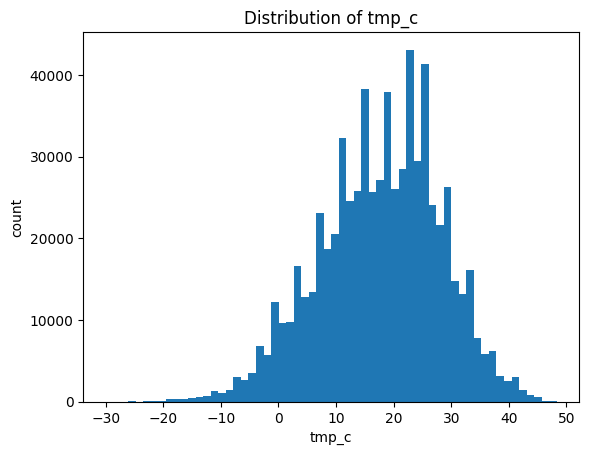

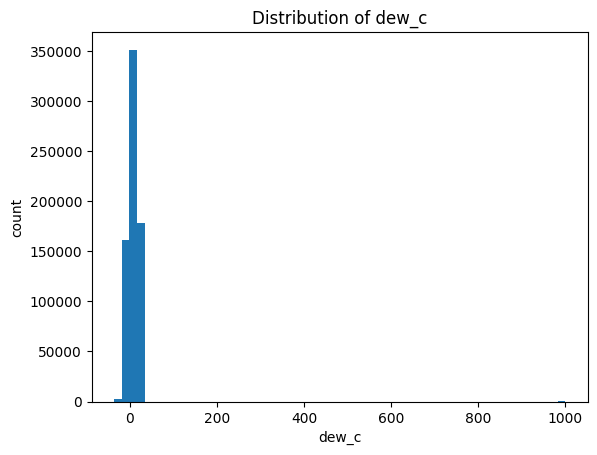

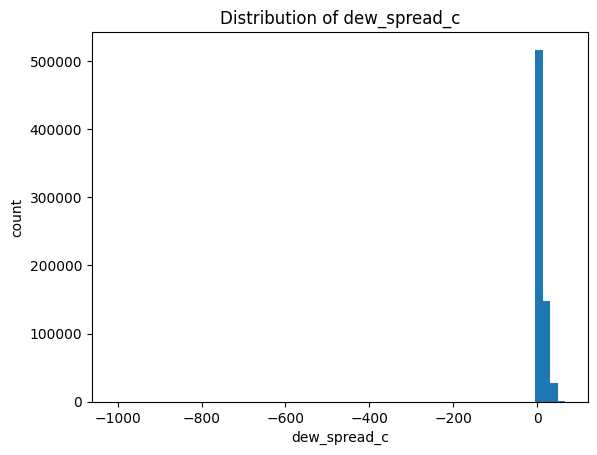

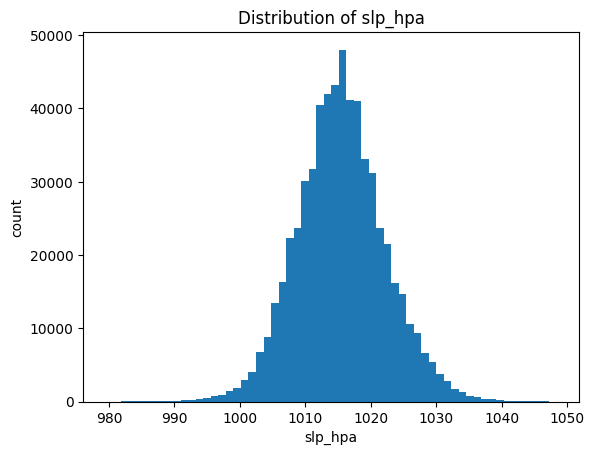

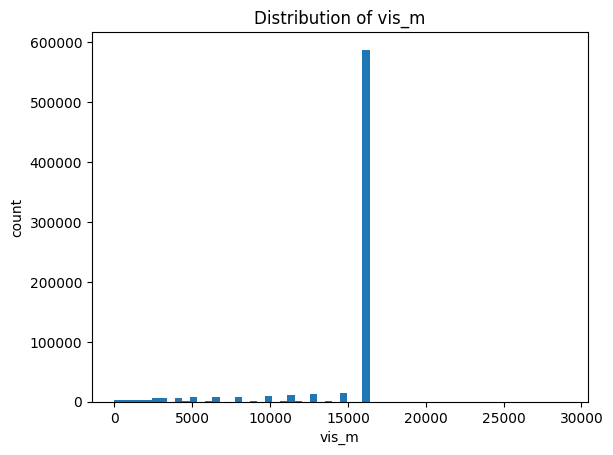

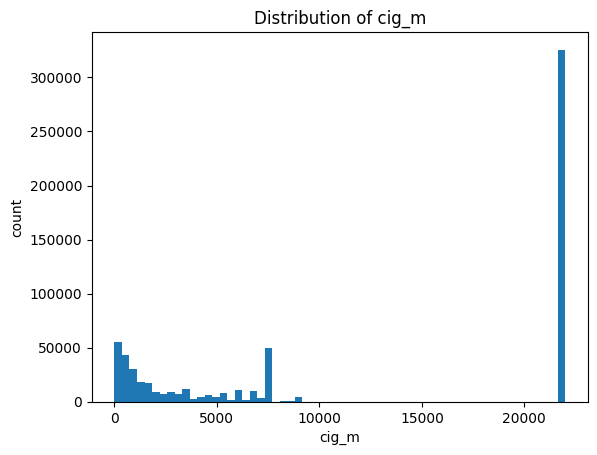

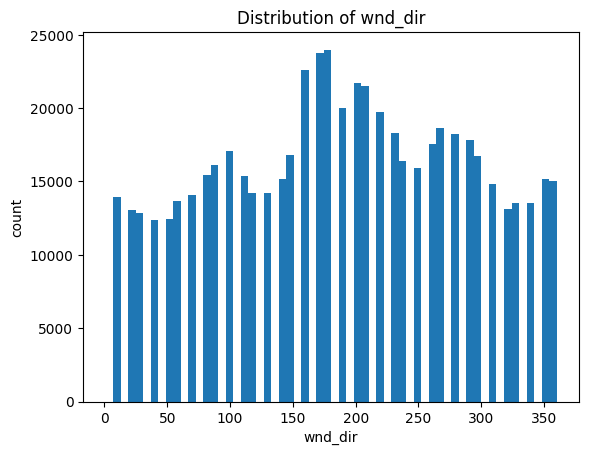

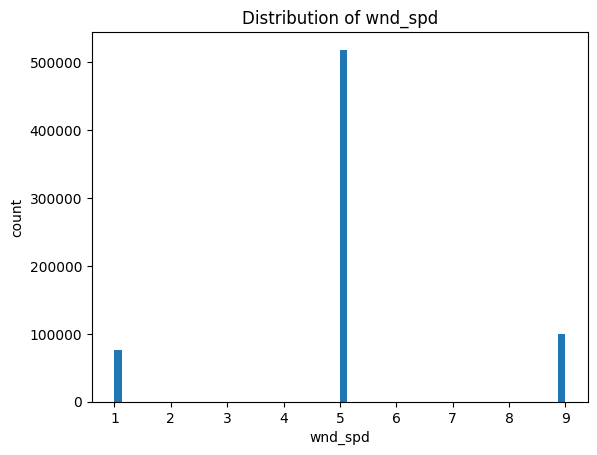

In [11]:
numeric_cols = ['tmp_c','dew_c','dew_spread_c','slp_hpa','vis_m','cig_m','wnd_dir','wnd_spd']
for col in numeric_cols:
    if col in df.columns:
        plt.figure()
        df[col].plot.hist(bins=60)
        plt.xlabel(col)
        plt.ylabel('count')
        plt.title(f'Distribution of {col}')
        plt.show()


## 4) Seasonal Patterns

<Figure size 640x480 with 0 Axes>

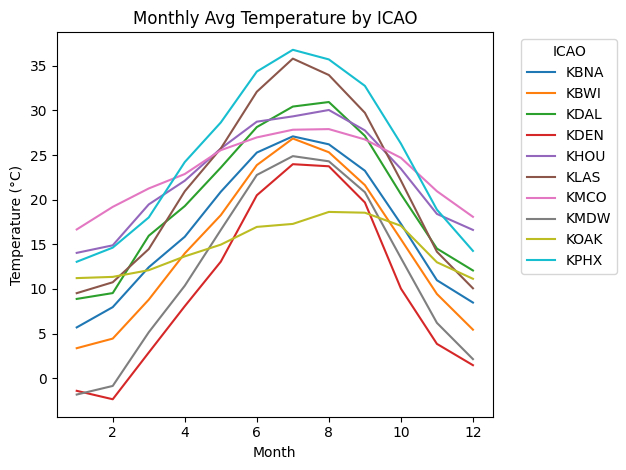

<Figure size 640x480 with 0 Axes>

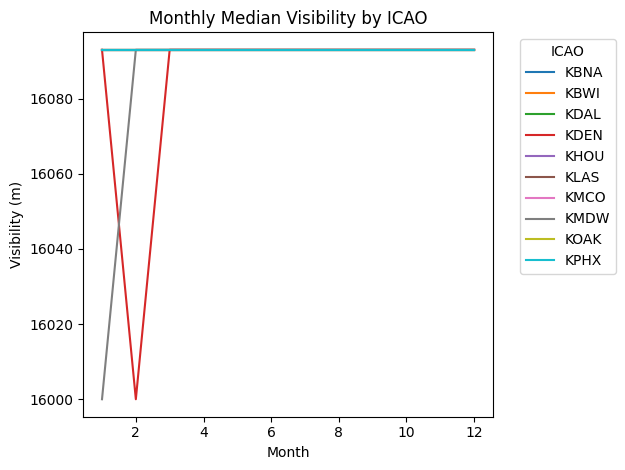

In [12]:
if {'month','ICAO','tmp_c'}.issubset(df.columns):
    monthly_tmp = df.groupby(['ICAO','month'])['tmp_c'].mean().unstack(0)
    plt.figure()
    monthly_tmp.plot()
    plt.title('Monthly Avg Temperature by ICAO')
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.legend(title='ICAO', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if {'month','ICAO','vis_m'}.issubset(df.columns):
    monthly_vis = df.groupby(['ICAO','month'])['vis_m'].median().unstack(0)
    plt.figure()
    monthly_vis.plot()
    plt.title('Monthly Median Visibility by ICAO')
    plt.xlabel('Month')
    plt.ylabel('Visibility (m)')
    plt.legend(title='ICAO', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 5) Correlations (numeric only)

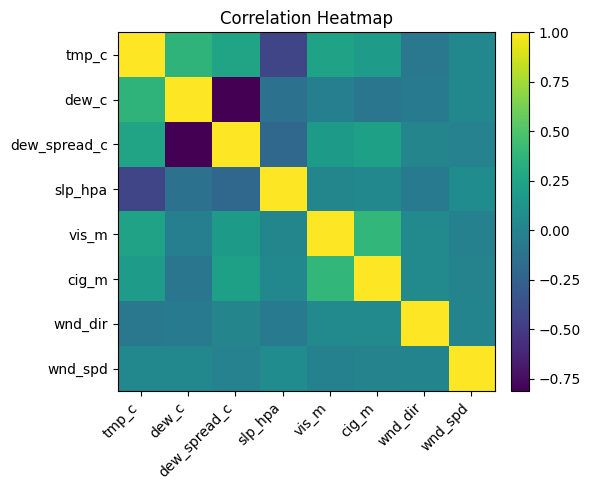

In [13]:
num_present = [c for c in numeric_cols if c in df.columns]
if len(num_present) >= 2:
    corr = df[num_present].corr()
    plt.figure(figsize=(6,5))
    im = plt.imshow(corr, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(num_present)), num_present, rotation=45, ha='right')
    plt.yticks(range(len(num_present)), num_present)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    corr
else:
    print('Not enough numeric columns to compute correlations.')


## 6) Airport-Level Summaries

In [14]:
summary_cols = ['tmp_c','dew_c','slp_hpa','vis_m','cig_m','wnd_spd']
avail = [c for c in summary_cols if c in df.columns]
if 'ICAO' in df.columns and avail:
    agg = df.groupby('ICAO')[avail].agg(['mean','median','std','min','max']).round(2)
    agg
else:
    print('Missing ICAO or summary columns.')


## 7) Outlier Checks (simple)

In [15]:
def iqr_outlier_mask(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return (s < (q1 - k*iqr)) | (s > (q3 + k*iqr))

for col in ['tmp_c','slp_hpa','vis_m','wnd_spd']:
    if col in df.columns:
        mask = iqr_outlier_mask(df[col].dropna())
        rate = mask.mean() if hasattr(mask, 'mean') else float(mask.sum())/len(mask)
        print(f"Outlier rate for {col}: {rate:.2%}")


Outlier rate for tmp_c: 0.43%
Outlier rate for slp_hpa: 1.53%
Outlier rate for vis_m: 15.26%
Outlier rate for wnd_spd: 25.22%


## 8) Save a Trimmed, Model-Ready Subset (optional)

In [ ]:
model_cols = ['ICAO','DATE','tmp_c','dew_c','slp_hpa','vis_m','cig_m','wnd_dir','wnd_spd']
present = [c for c in model_cols if c in df.columns]
df_model = df[present].dropna()
out_dir = csv_path.parent  # same folder as the CSV
out_path = out_dir / 'hourly_features_modelready.parquet'
df_model.to_parquet(out_path, index=False)
print(f"Saved model-ready file: {out_path}  (rows={len(df_model):,})")
